# 04. Explainability (SHAP) và Đề xuất kinh doanh: Telco Customer Churn

Dùng SHAP để giải thích vì sao mô hình dự đoán một khách hàng cụ thể có nguy cơ rời bỏ
cao hay thấp, xác định nhóm khách hàng rủi ro cao theo yếu tố cụ thể, và đề xuất chiến
lược giữ chân theo phân khúc.

## 0. Mục tiêu notebook

- Tổng thể: yếu tố nào đẩy churn lên, yếu tố nào kéo xuống, và theo hướng
  nào.
- Nhìn từng khách cụ thể: khách rủi ro cao/thấp, và trường hợp
  model đoán sai, để hiểu vì sao model đưa ra kết luận đó.
- Chốt lại đề xuất hành động cụ thể theo từng nhóm khách, gắn với chi phí thực
  tế đã tính ở bước trước.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

import features as fe

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models'
RAW_DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

## 1. Dữ liệu và mô hình

Dùng mô hình đã chọn và tập dữ liệu đã tách ở bước trước. Test set chỉ để minh
hoạ.

In [2]:
model_artifact = joblib.load(f'{MODELS_DIR}/best_model.joblib')
model = model_artifact['model']
threshold = model_artifact['threshold']
feature_columns = model_artifact['feature_columns']

print('Model    :', model_artifact['model_name'],
      f"({model_artifact['data_variant']}, {model_artifact['hyperparams']})")
print('Threshold:', threshold)
print('ROC-AUC  : validation =', round(model_artifact['val_roc_auc'], 4),
      '| test =', round(model_artifact['test_roc_auc'], 4))

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv').set_index('customerID')
val_df = pd.read_csv(f'{PROCESSED_DIR}/val.csv').set_index('customerID')
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv').set_index('customerID')

X_train, y_train = train_df[feature_columns], train_df['Churn']
X_val, y_val = val_df[feature_columns], val_df['Churn']
X_test, y_test = test_df[feature_columns], test_df['Churn']

_, _, df_readable = fe.build_dataset(RAW_DATA_PATH)

print('X_train:', X_train.shape, '| X_val:', X_val.shape, '| X_test:', X_test.shape)

Model    : Logistic Regression (class_weight, {'clf__C': np.float64(21.368329072358772)})
Threshold: 0.15000000000000002
ROC-AUC  : validation = 0.8396 | test = 0.8452


X_train: (4225, 29) | X_val: (1409, 29) | X_test: (1409, 29)


## 2. Tính mức đóng góp của từng yếu tố (SHAP)


**Giar định:** 
- Cách tính này giả định các yếu tố độc lập với nhau, trong khi vài nhóm yếu
tố trong dữ liệu thực ra có liên quan lẫn nhau (ví dụ loại hợp đồng). 
- Đã thử cách tính chính xác hơn, mức chênh lệch không đáng kể ở quy mô dữ liệu này, nên dùng cách đơn giản.

In [3]:
scaler = model.named_steps['scaler']
clf = model.named_steps['clf']

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_columns, index=X_test.index)

masker = shap.maskers.Independent(X_train_scaled, max_samples=len(X_train_scaled))
explainer = shap.LinearExplainer(clf, masker)
shap_values = explainer(X_test_scaled)

# Kiểm chứng: SHAP values + base value phải cộng đúng bằng log-odds (decision_function) gốc
logit_direct = clf.decision_function(X_test_scaled.values)
logit_from_shap = shap_values.values.sum(axis=1) + shap_values.base_values
print('Kiểm tra tính cộng dồn (max abs diff, phải ~0):',
      np.max(np.abs(logit_direct - logit_from_shap)))
print('shap_values shape:', shap_values.values.shape)
print('base value (log-odds trung bình khi chưa biết gì về khách hàng):',
      round(shap_values.base_values[0], 4))

Kiểm tra tính cộng dồn (max abs diff, phải ~0): 1.7763568394002505e-15
shap_values shape: (1409, 29)
base value (log-odds trung bình khi chưa biết gì về khách hàng): -0.6862


## 3. Yếu tố nào ảnh hưởng churn nhiều nhất, và theo hướng nào

Mỗi chấm trong biểu đồ là 1 khách hàng trong test set. Màu chấm thể hiện giá trị gốc của
yếu tố đó (đỏ = cao, xanh = thấp). 

Trục ngang thể hiện mức đẩy nguy cơ churn. Nhìn được cả mức độ quan trọng lẫn hướng tác động trong cùng 1 biểu
đồ.

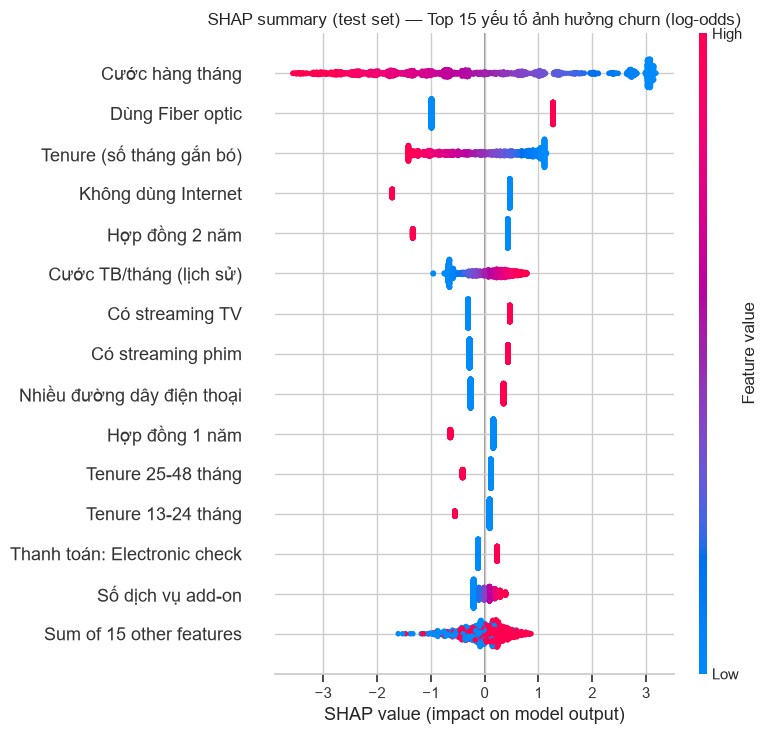

In [4]:
FEATURE_LABELS_VN = {
    'tenure': 'Tenure (số tháng gắn bó)',
    'MonthlyCharges': 'Cước hàng tháng',
    'TotalCharges': 'Tổng cước đã trả',
    'AvgMonthlySpend': 'Cước TB/tháng (lịch sử)',
    'NumAddonServices': 'Số dịch vụ add-on',
    'Contract_One year': 'Hợp đồng 1 năm',
    'Contract_Two year': 'Hợp đồng 2 năm',
    'InternetService_Fiber optic': 'Dùng Fiber optic',
    'InternetService_No': 'Không dùng Internet',
    'PaymentMethod_Electronic check': 'Thanh toán: Electronic check',
    'PaymentMethod_Credit card (automatic)': 'Thanh toán: thẻ tín dụng (tự động)',
    'PaymentMethod_Mailed check': 'Thanh toán: Mailed check',
    'PaperlessBilling': 'Hoá đơn điện tử',
    'SeniorCitizen': 'Khách cao tuổi',
    'Partner': 'Có vợ/chồng',
    'Dependents': 'Có người phụ thuộc',
    'PhoneService': 'Dùng dịch vụ điện thoại',
    'MultipleLines': 'Nhiều đường dây điện thoại',
    'OnlineSecurity': 'Có bảo mật online',
    'OnlineBackup': 'Có sao lưu online',
    'DeviceProtection': 'Có bảo vệ thiết bị',
    'TechSupport': 'Có hỗ trợ kỹ thuật',
    'StreamingTV': 'Có streaming TV',
    'StreamingMovies': 'Có streaming phim',
    'gender': 'Giới tính (1 = Nữ)',
    'tenure_bucket_7-12': 'Tenure 7-12 tháng',
    'tenure_bucket_13-24': 'Tenure 13-24 tháng',
    'tenure_bucket_25-48': 'Tenure 25-48 tháng',
    'tenure_bucket_49-72': 'Tenure 49-72 tháng',
}
readable_names = [FEATURE_LABELS_VN.get(c, c) for c in feature_columns]

# Explanation (SHAP 0.52) không có .copy() -> gán feature_names trực tiếp lên object
# (an toàn: object này không cần giữ tên cột kỹ thuật gốc ở các bước sau).
shap_values.feature_names = readable_names
shap_values_display = shap_values

plt.figure(figsize=(8, 7))
shap.plots.beeswarm(shap_values_display, max_display=15, show=False)
plt.title('SHAP summary (test set) — Top 15 yếu tố ảnh hưởng churn (log-odds)')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Đối chiếu với các phân tích trước đó

Xếp hạng theo mức đóng góp trung bình của từng yếu tố trên test set, giá trị càng cao
càng ảnh hưởng nhiều đến dự đoán churn.

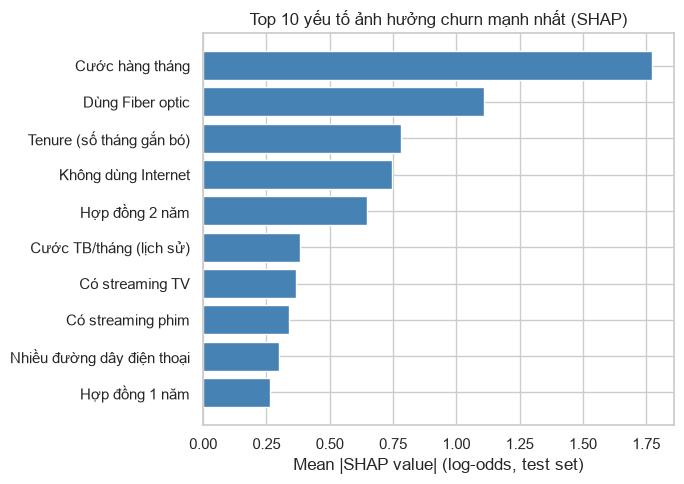

Top 10 theo SHAP:
  1. Cước hàng tháng (MonthlyCharges): 1.771
  2. Dùng Fiber optic (InternetService_Fiber optic): 1.111
  3. Tenure (số tháng gắn bó) (tenure): 0.780
  4. Không dùng Internet (InternetService_No): 0.746
  5. Hợp đồng 2 năm (Contract_Two year): 0.647
  6. Cước TB/tháng (lịch sử) (AvgMonthlySpend): 0.383
  7. Có streaming TV (StreamingTV): 0.365
  8. Có streaming phim (StreamingMovies): 0.337
  9. Nhiều đường dây điện thoại (MultipleLines): 0.298
  10. Hợp đồng 1 năm (Contract_One year): 0.264


In [5]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_columns
).sort_values(ascending=False)

top10 = mean_abs_shap.head(10)
top10_labels = [FEATURE_LABELS_VN.get(c, c) for c in top10.index]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top10_labels[::-1], top10.values[::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value| (log-odds, test set)')
ax.set_title('Top 10 yếu tố ảnh hưởng churn mạnh nhất (SHAP)')
plt.tight_layout()
plt.savefig('../reports/figures/shap_top10_bar.png', dpi=150)
plt.show()

print('Top 10 theo SHAP:')
for i, (col, val) in enumerate(top10.items(), 1):
    print(f'  {i}. {FEATURE_LABELS_VN.get(col, col)} ({col}): {val:.3f}')

**Nhận xét:** thứ tự top 10 gần như trùng khớp với xếp hạng theo hệ số mô hình ở bước
trước (cước hàng tháng, dùng Fiber optic, thời gian gắn bó, không dùng Internet, hợp
đồng 2 năm đều nằm top 5 ở cả 2 cách tính). Cũng nhất quán với phân tích dữ liệu ban đầu:
loại hợp đồng và loại dịch vụ Internet đều nằm trong nhóm ảnh hưởng mạnh nhất theo cả 3
cách nhìn độc lập, củng cố độ tin cậy của kết luận.

## 5. Giải thích cho khách hàng cụ thể

Chọn 3 khách hàng minh hoạ trong test set (ở ngưỡng đã chọn = 0,15):
- **(a)** Rủi ro churn cao nhất, model dự đoán đúng.
- **(b)** Rủi ro churn thấp nhất, model dự đoán đúng, khách hàng trung thành điển hình.
- **(c)** Một trường hợp model dự đoán nhầm, minh hoạ luôn cả giới hạn của model, không
  chỉ điểm mạnh.

In [6]:
proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= threshold).astype(int)

results_test = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': pred_test,
    'proba': proba_test,
}, index=X_test.index)

tp = results_test[(results_test['y_true'] == 1) & (results_test['y_pred'] == 1)].sort_values('proba', ascending=False)
tn = results_test[(results_test['y_true'] == 0) & (results_test['y_pred'] == 0)].sort_values('proba')
fp = results_test[(results_test['y_true'] == 0) & (results_test['y_pred'] == 1)].sort_values('proba', ascending=False)

customer_high_risk = tp.index[0]
customer_low_risk = tn.index[0]
customer_false_positive = fp.index[0]

print(f'(a) Khách hàng rủi ro cao (TP)     : {customer_high_risk} | proba = {tp.iloc[0]["proba"]:.3f}')
print(f'(b) Khách hàng rủi ro thấp (TN)    : {customer_low_risk} | proba = {tn.iloc[0]["proba"]:.3f}')
print(f'(c) Khách hàng model dự đoán nhầm (FP): {customer_false_positive} | proba = {fp.iloc[0]["proba"]:.3f}')

(a) Khách hàng rủi ro cao (TP)     : 5178-LMXOP | proba = 0.960
(b) Khách hàng rủi ro thấp (TN)    : 0794-YVSGE | proba = 0.007
(c) Khách hàng model dự đoán nhầm (FP): 2545-EBUPK | proba = 0.955


In [7]:
PROFILE_COLS = ['tenure', 'Contract', 'InternetService', 'PaymentMethod',
                'MonthlyCharges', 'PaperlessBilling', 'OnlineSecurity', 'TechSupport']


def explain_customer(customer_id, title, save_path=None):
    idx = X_test.index.get_loc(customer_id)
    single_display = shap_values[idx]
    single_display.feature_names = readable_names

    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(single_display, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Hồ sơ khách hàng {customer_id} (xác suất churn dự đoán = {proba_test[idx]:.3f}):')
    display(df_readable.loc[[customer_id], PROFILE_COLS])

### (a) Khách hàng rủi ro churn cao nhất (True Positive)

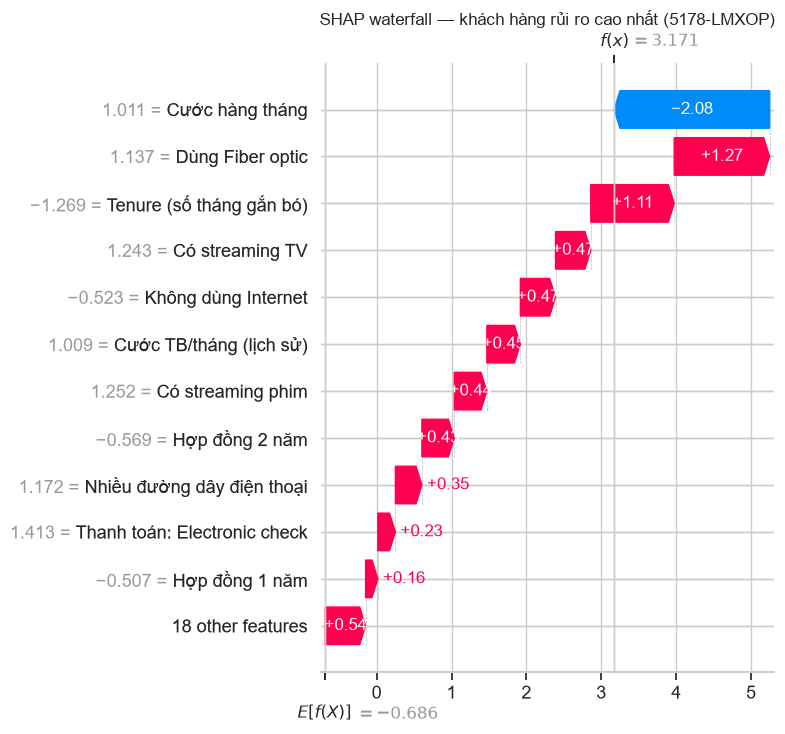

Hồ sơ khách hàng 5178-LMXOP (xác suất churn dự đoán = 0.960):


,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,PaperlessBilling,OnlineSecurity,TechSupport
customerID,,,,,,,,
5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.1,Yes,No,No


In [8]:
explain_customer(
    customer_high_risk,
    f'SHAP waterfall — khách hàng rủi ro cao nhất ({customer_high_risk})',
    save_path='../reports/figures/shap_waterfall_high_risk.png',
)

### (b) Khách hàng rủi ro churn thấp nhất (True Negative)

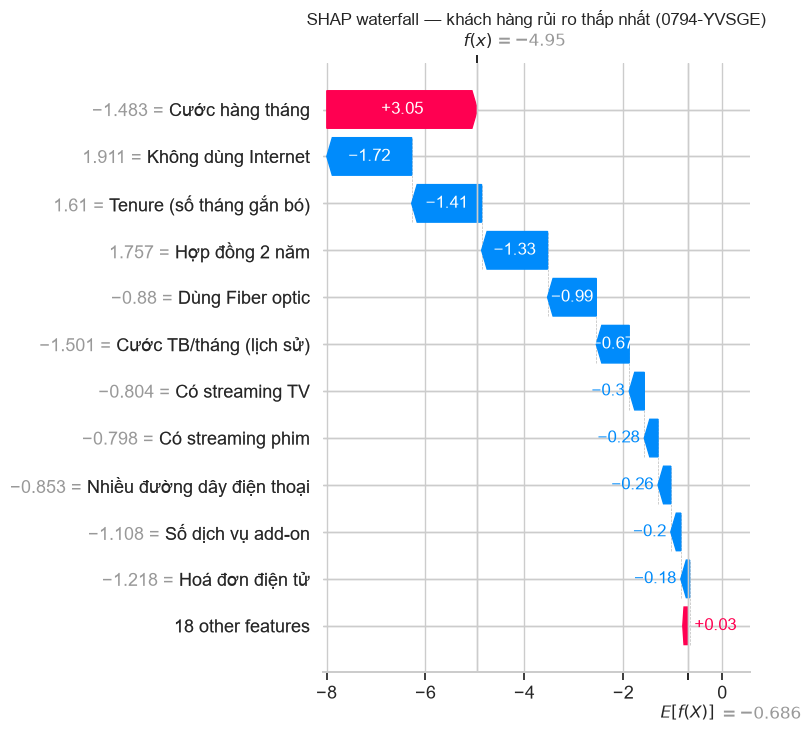

Hồ sơ khách hàng 0794-YVSGE (xác suất churn dự đoán = 0.007):


,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,PaperlessBilling,OnlineSecurity,TechSupport
customerID,,,,,,,,
0794-YVSGE,72,Two year,No,Bank transfer (automatic),20.3,No,No,No


In [9]:
explain_customer(
    customer_low_risk,
    f'SHAP waterfall — khách hàng rủi ro thấp nhất ({customer_low_risk})',
)

### (c) Trường hợp model dự đoán nhầm, minh hoạ giới hạn model

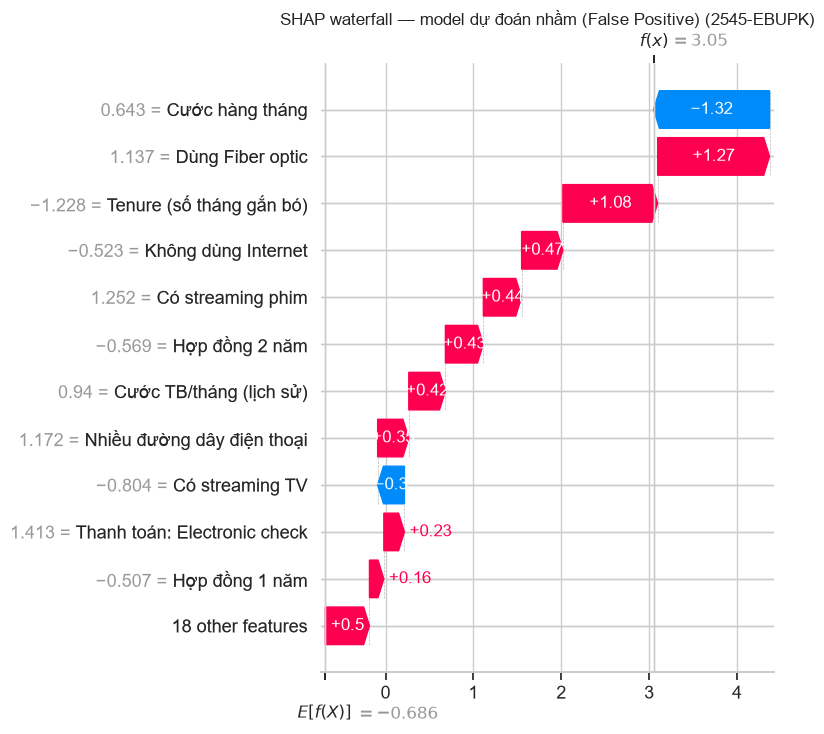

Hồ sơ khách hàng 2545-EBUPK (xác suất churn dự đoán = 0.955):


,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,PaperlessBilling,OnlineSecurity,TechSupport
customerID,,,,,,,,
2545-EBUPK,2,Month-to-month,Fiber optic,Electronic check,84.05,Yes,No,No


In [10]:
explain_customer(
    customer_false_positive,
    f'SHAP waterfall — model dự đoán nhầm (False Positive) ({customer_false_positive})',
)

**Nhận xét từ 3 ví dụ:** 
- Khách hàng rủi ro cao (a) thường hội tụ nhiều yếu tố bất lợi
cùng lúc (hợp đồng ngắn hạn, thời gian gắn bó thấp, cước cao, ít dùng thêm dịch vụ),
không phải do 1 yếu tố đơn lẻ quyết định. 

- Khách hàng rủi ro thấp (b) thường có thời gian
gắn bó dài và hợp đồng dài hạn, Không dùng Internet là yếu tố làm giảm rủi ro churn nhiều nhất. 

- Trường hợp dự đoán nhầm (c) cho thấy giới hạn thực tế: ngưỡng dự đoán thấp (0,15) giúp bắt được
nhiều khách sắp churn hơn, nhưng đổi lại có nhiều cảnh báo nhầm hơn. Chi phí này đã được
tính rõ (1 tháng cước ưu đãi) trong ma trận chi phí, không phải điều bất ngờ.

## 6. Đề xuất chiến lược giữ chân theo phân khúc rủi ro

1. **Ưu tiên hàng đầu: khách hợp đồng theo tháng, đặc biệt trong 6 tháng đầu.** Đây là
   nhóm rủi ro cao nhất theo cả 3 cách phân tích độc lập. Nên chủ động liên hệ trong 3
   tháng đầu tiên, thời điểm rủi ro rời bỏ cao nhất (nhóm mới dùng dưới 6 tháng có tỷ lệ
   churn 52,9%), 
   - Đề nghị 1 tháng cước miễn phí đổi lấy cam kết hợp đồng 1 năm.

2. **Nhóm dùng Fiber optic và thanh toán qua Electronic check là tổ hợp rủi ro cao
   nhất.** Khi kết hợp đủ 4 điều kiện (hợp đồng theo tháng, dùng Fiber optic, thanh toán
   Electronic check, mới dùng dưới 6 tháng), tỷ lệ churn khoảng 76-79%. Kiểm chứng trên test set là 78,8% (khoảng tin cậy 95%). Áp dụng cho toàn bộ khách hàng cho ra danh sách 410 khách cần ưu tiên.
   - Nên khảo sát nhanh lý do rời bỏ của nhóm dùng Fiber optic, đồng thời khuyến khích
   chuyển sang thanh toán tự động.

3. **Khách cước cao nhưng ít dùng thêm dịch vụ cũng là nhóm rủi ro cao** (nhóm chỉ dùng
   1 dịch vụ thêm có tỷ lệ churn cao nhất, 45,8%). 
   - Nên upsell các dịch vụ như bảo mật
   online, hỗ trợ kỹ thuật, không chỉ như nguồn doanh thu phụ mà còn giúp giữ chân khách
   hàng.

4. **Áp dụng đúng ngưỡng 0,15 khi triển khai thực tế**, ưu tiên ngân sách giữ chân cho
   khách có xác suất churn dự đoán từ 0,15 trở lên (không phải mặc định 0,5). Cách này
   đã được chứng minh giúp tiết kiệm 84,7% chi phí so với không dùng mô hình, và 35,9%
   so với dùng ngưỡng mặc định.

**Giới hạn:** cách tính SHAP ở đây giả định các yếu tố độc lập, đơn giản hoá cho mô hình
tuyến tính. Đủ tin cậy để xếp hạng mức độ quan trọng và hướng tác động, nhưng không nên
xem từng con số SHAP như một mức chi phí/lợi ích chính xác tuyệt đối cho từng khách
hàng.

## 7. Tóm tắt và bước tiếp theo

- Phân tích SHAP cho mô hình đã chọn.
- Kết quả xác nhận lại các yếu tố quan trọng nhất đã biết từ trước (loại hợp đồng, loại
  dịch vụ Internet, thời gian gắn bó, cước hàng tháng).
- Giải thích 3 khách hàng cụ thể (rủi ro cao, rủi ro thấp, dự đoán nhầm) để thấy vì sao
  mô hình đưa ra dự đoán.
- Chốt đề xuất kinh doanh cụ thể theo phân khúc rủi ro, gắn với ma trận chi phí đã có.

**Bước tiếp theo:** tổng hợp báo cáo cuối.